## Setup

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp/Project.toml`
  [13f3f980] CairoMakie v0.15.10
  [074ae576] CarloAnalysis v1.0.0-DEV `https://github.com/PatXue/CarloAnalysis.jl#main`
  [033835bb] JLD2 v0.6.4
  [eff96d63] Measurements v2.14.1
  [295af30f] Revise v3.14.3
  [a601b020] WignerMolecule v1.0.0-DEV `..`
  [37e2e46d] LinearAlgebra v1.12.0


In [2]:
include("Expectation.jl")
using .Expectations
using CairoMakie
using CarloAnalysis
using JLD2
using LinearAlgebra
using Measurements

In [77]:
function Measurements.measurement(e::Expectation)
    return e.val ± e.err
end

function cumulant(moms::Vector{T}, ord) where {T <: Real}
    M = Matrix{T}(undef, ord, ord)
    for I in eachindex(IndexCartesian(), M)
        i, j = Tuple(I)
        mom = i-j < 0 ? 1 : moms[i-j+1]
        M[I] = mom * binomial(i-1, max(j-2, 0))
    end
    return (-1)^(ord+1) * det(M)
end

"""
    getexpansion(name, ord)

Read high-T expansion coefficients for energy from JLD2 file to order ord,
returns closure accepting T
"""
function getexpansion(name, ord)
    all_data = load("expectations.jld2")
    energies = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = [cumulant(energies, i) for i in 1:(ord+1)]
    return T -> getfield.(sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants), :val) ./ 64
end

"""
    getexpansion(name, ord, symbol)

TBW
"""
function getexpansion(name, ord, symbol)
    all_data = load("expectations.jld2")
    As = [measurement(all_data["$name/$(symbol)H$i"]) for i in 0:ord]
    Hs = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = Vector{Float64}(undef, ord+1)
    for i in 1:(ord+1)
        if i == 1
            cumulant = As[1]
        elseif i == 2
            cumulant = As[2] - Hs[1]*As[1]
        elseif i == 3
            cumulant = As[3] - 2*Hs[1]*As[2] - Hs[2]*As[1] + 2*Hs[1]^2*As[1]
        elseif i == 4
            cumulant = As[4] - 3*Hs[1]*As[3] - 3*Hs[2]As[2] - Hs[3]*As[1] +
                6*Hs[1]^2*As[2] + 6*Hs[2]*Hs[1]*As[1] - 6*Hs[1]^3*As[1]
        else
            cumulant = 0 ± 0
        end
        cumulants[i] = cumulant.val
    end
    return T -> sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants)
end

getexpansion

In [73]:
all_data = load("expectations.jld2")
[measurement(all_data["stripe/ηH$i"]) for i in 0:5]

6-element Vector{Measurement{Float64}}:
 0.0104189 ± 3.3e-6
    3.5e-5 ± 5.0e-5
   1.19215 ± 0.00085
     -0.65 ± 0.022
    410.38 ± 0.62
    -753.0 ± 21.0

## Stripe

In [44]:
results = JobResult("../jobs", "stripe-high-t")

JobResult("../jobs", "stripe-high-t", 25×57 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     η ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
   2 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   4 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   5 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
   6 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   7 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
  ⋮  │                 ⋮                                  ⋮              

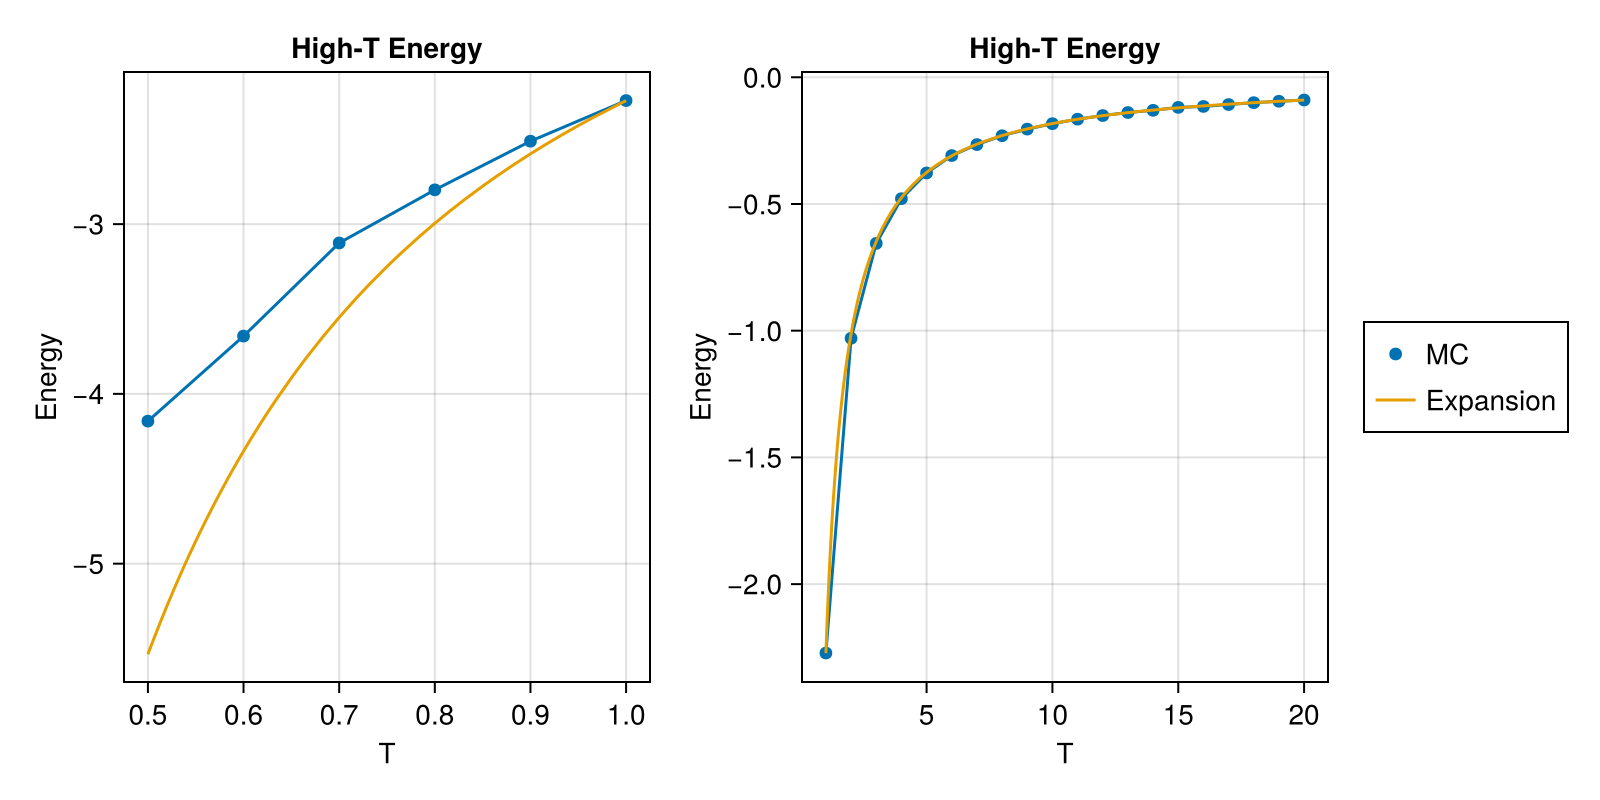

In [64]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, results.data[results.data.T .<= 1, :])
lines!(ax1, 0.5..1, getexpansion("stripe", 2))
fig[1,2] = ax2 = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax2, :T, :Energy, results.data[results.data.T .> 0.95, :], label="MC")
lines!(ax2, 1..20, getexpansion("stripe", 2), label="Expansion")
Legend(fig[1,3], ax2)
fig

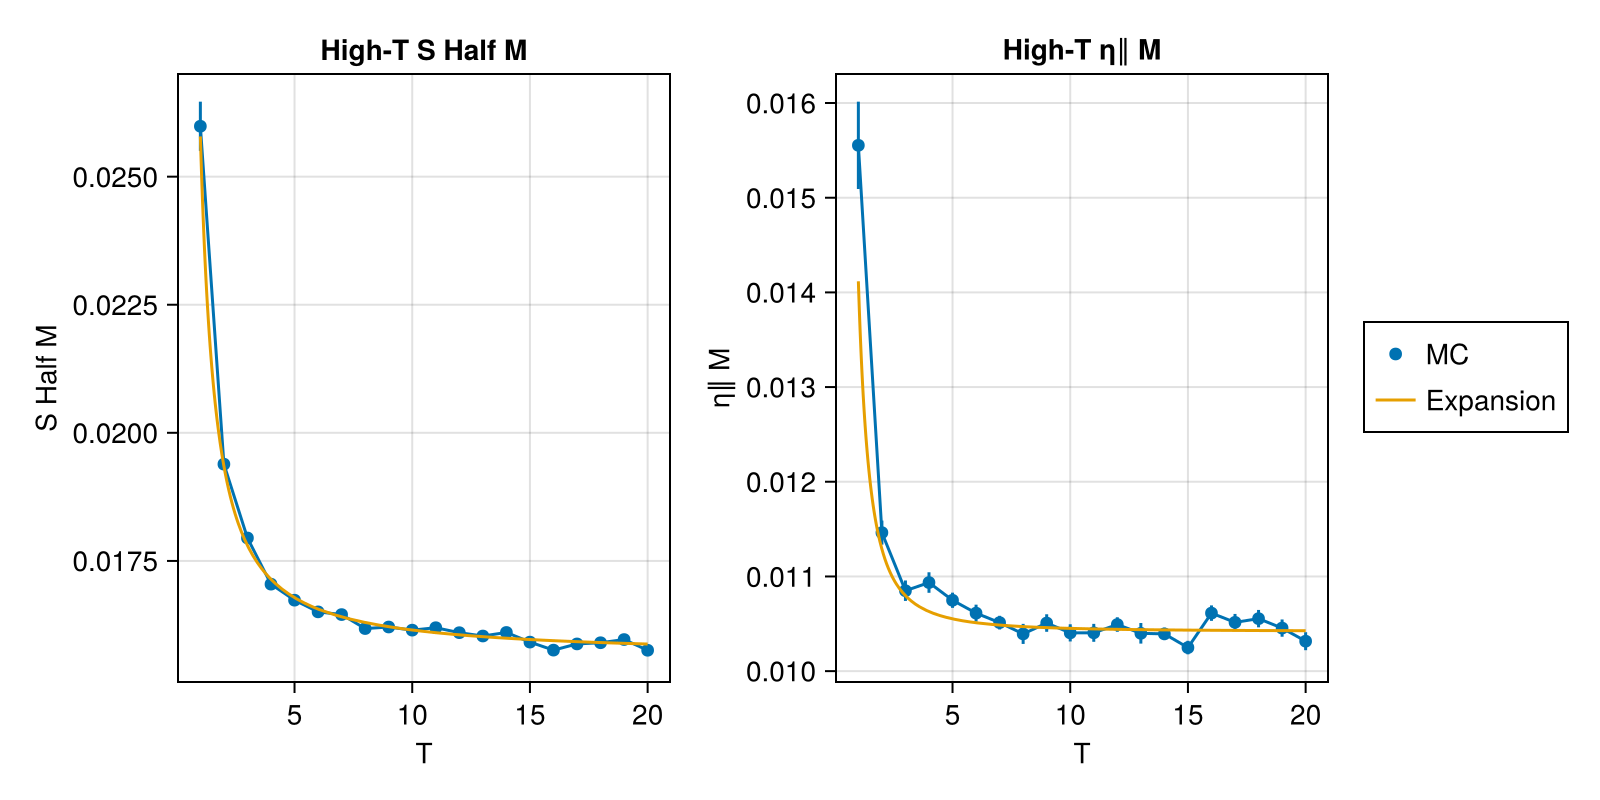

In [76]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S Half M", xlabel="T", ylabel="S Half M")
generate_plot!(ax1, :T, :sk_corr_half_M, results.data[results.data.T .>= 1,:])
lines!(ax1, 1..20, getexpansion("stripe", 3, "s"))
fig[1,2] = ax2 = Axis(fig, title="High-T η∥ M", xlabel="T", ylabel="η∥ M")
generate_plot!(ax2, :T, :ηk_corr_M, results.data[results.data.T .>= 1,:], label="MC") do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
lines!(ax2, 1..20, getexpansion("stripe", 3, "η"), label="Expansion")
Legend(fig[1,3], ax2)
fig